## 10. 3D Image analysis with cartographic projections

**Note:** this tutorial is currently a stub - sorry!

A main advantage of cartographically projecting 3D data to 2D is that it makes quantitative analysis significantly easier, for example:

- segmenting cells and measuring their shape
- quantifying intensity and anisotropy of fluorescent signals
- measuring morphogenetic tissue flows and tissue deformation

But we have to keep in mind that our data really comes from a 3D shape: when analyzing data in cartographic projections, we have to make sure we are always accounting for mapping distortion and curvature. Think of Greenland on a Mercator projection of the globe. 
Importantly, however, _image intensities_ are not distorted by cartographic projection. The `.tif` output of `blender_tissue_cartography` is a faithful reflection of the image intensities in the original 3D data (however, the created blender textures are _not_: for them, brightness and constrast are automatically normalized for visualization). You only need to worry about cartographic distortion when measuring _shapes_.

There are two ways you can do this:

1. _Mapping back to 3D_: it is conceptually easiest and most robust to map whatever object you detected in the 2D image back to 3D, and carry out your quantifications in 3D. For example, after segmenting out an cell, you can map its outline back into 3D. For this purpose, `blender_tissue_cartography` always saves a second `.tif` file together with your projected data, which specifies the 3D coordinates of each pixel. 

2. _Correcting for distortion in 2D_: you can use `blender_tissue_cartography` to correct distortion directly in 2D. For example, if you want to measure the area of a cell in 2D, you can compute the area-distortion (how much a given region in the 2D projection is inflated/deflated compared to 3D), and use that to correct for the distortion. More generally, you can compute the _induced metric_ in 2D, allowing for correct angle measurements as well.

The relevant tools are provided and explained in the [`diffgeo` module](https://nikolas-claussen.github.io/blender-tissue-cartography/Python%20library/differential_geometry.html).

### Example: cell segmentation

Here is an example: a volumetric recording of _Arabidposis_ flower buds (shared by Dr. An Yan). After extracting and unwrapping the surface, we can easily segment our cells. But to properly measure the area, we need to take cartographic area distortion into account. We can compute it using `diffgeo.get_area_distortion_in_UV`. The correct, 3D areas can then be computed using the average distortion factor across each cell.

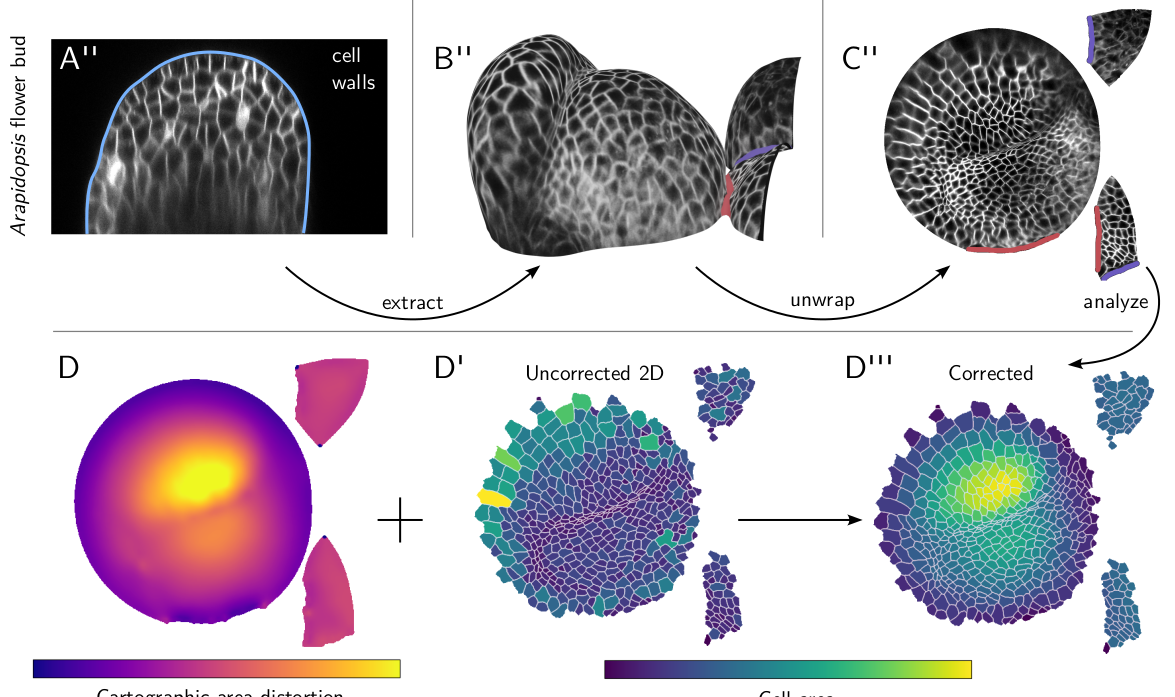



### Vector calculus

For quantitative analysis of changing shapes, one often uses flow or deformation vector fields. For instance, you can use particle image velocimetry, optical flow, or simple cell tracking in 2D projected images to see how cells are moving on top of your 3D surface. 
Using the `diffgeo` module, you can map these vector fields from 2D where you computed them back to 3D, and analyze them using the (maybe) familiar tools of vector calculus like $\nabla\cdot$ and $\nabla \times$.


**Note** If your 3D surface is also deforming, you need to _add_ the motion _on_ and the motion _of_ the surface. If you use the _reference mesh_ approach to dynamic data (tutorial 9), it is straightforward to compute the motion _of_ the surface at each position in the 2D projection: just take the difference between the associated 3D coordinates at subsequent timepoints.
